In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rmisra/news-category-dataset")

print("Path to dataset files:", path)

100%|██████████| 26.5M/26.5M [00:00<00:00, 131MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/rmisra/news-category-dataset/versions/3


In [2]:
import pandas as pd
import json

path+="/News_Category_Dataset_v3.json"
df = pd.read_json(path, lines=True)

In [3]:
df.shape

(209527, 6)

In [4]:
df.head()

,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23
3,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23
4,https://www.huffpost.com/entry/amy-cooper-lose...,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22


In [5]:
df['text'] = df['headline'] + ' ' + df['short_description']

print(df['category'].value_counts())
print(f"Total records: {len(df)}")
print(f"Categories: {df['category'].nunique()}")

category
POLITICS          35602
WELLNESS          17945
ENTERTAINMENT     17362
TRAVEL             9900
STYLE & BEAUTY     9814
PARENTING          8791
HEALTHY LIVING     6694
QUEER VOICES       6347
FOOD & DRINK       6340
BUSINESS           5992
COMEDY             5400
SPORTS             5077
BLACK VOICES       4583
HOME & LIVING      4320
PARENTS            3955
THE WORLDPOST      3664
WEDDINGS           3653
WOMEN              3572
CRIME              3562
IMPACT             3484
DIVORCE            3426
WORLD NEWS         3299
MEDIA              2944
WEIRD NEWS         2777
GREEN              2622
WORLDPOST          2579
RELIGION           2577
STYLE              2254
SCIENCE            2206
TECH               2104
TASTE              2096
MONEY              1756
ARTS               1509
ENVIRONMENT        1444
FIFTY              1401
GOOD NEWS          1398
U.S. NEWS          1377
ARTS & CULTURE     1339
COLLEGE            1144
LATINO VOICES      1130
CULTURE & ARTS     1074
EDUCATI

In [6]:
df.isnull().sum()

,0
link,0
headline,0
category,0
short_description,0
authors,0
date,0
text,0


In [7]:
print(df.duplicated().sum())
dupRow = df[df.duplicated()]
print(dupRow)

13
                                                     link  \
67677   https://www.huffingtonpost.comhttp://www.mothe...   
67923   https://www.huffingtonpost.comhttp://gizmodo.c...   
70239   https://www.huffingtonpost.comhttp://www.cnbc....   
139830  https://www.huffingtonpost.comhttp://www.cnn.c...   
144409  https://www.huffingtonpost.comhttp://www.upwor...   
145142  https://www.huffingtonpost.comhttp://www.weath...   
178155  https://www.huffingtonpost.comhttp://www.busin...   
187329  https://www.huffingtonpost.comhttp://www.nytim...   
194596  https://www.huffingtonpost.comhttp://blogs.wsj...   
194598  https://www.huffingtonpost.comhttp://www.theda...   
207122  https://www.huffingtonpost.comhttp://d.repubbl...   
207208  https://www.huffingtonpost.comhttp://d.repubbl...   
207318  https://www.huffingtonpost.comhttp://d.repubbl...   

                                                 headline        category  \
67677   On Facebook, Trump's Longtime Butler Calls For...        

In [8]:
df = df.drop_duplicates()

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

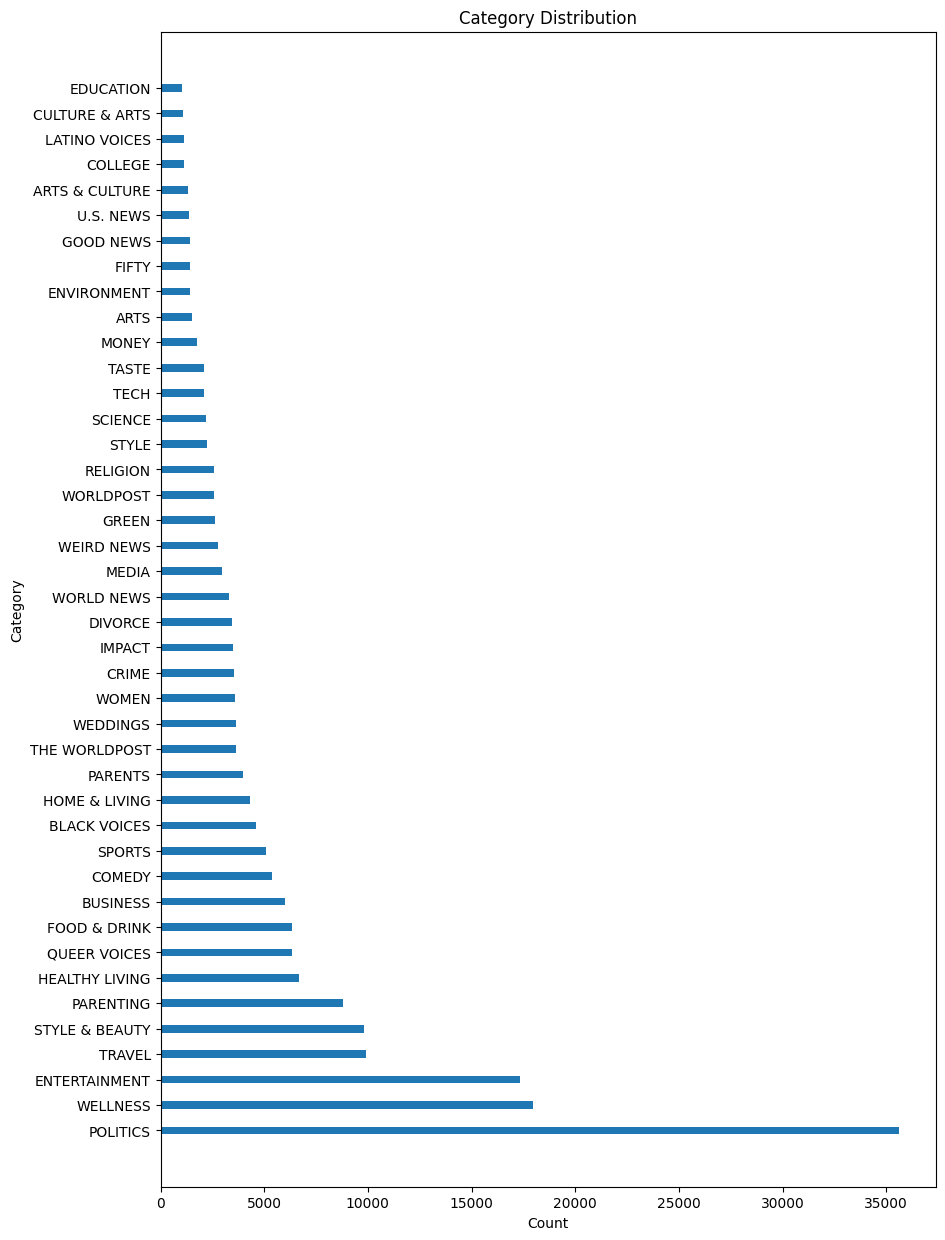

In [11]:
plt.figure(figsize=(10,15))
plt.barh(df['category'].value_counts().index, df['category'].value_counts().values,height=0.3)
plt.ylabel('Category')
plt.xlabel('Count')
plt.title('Category Distribution')
plt.show()


In [12]:
df['date'].dt.year.value_counts()

,count
date,
2013,34580
2014,32338
2016,32095
2015,32006
2012,31349
2017,29889
2018,9734
2021,2066
2020,2054


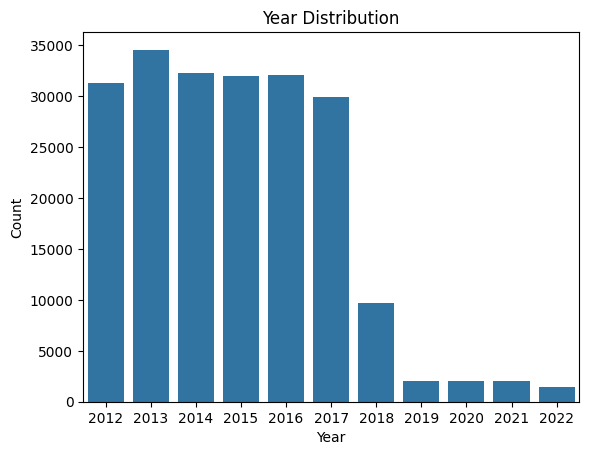

In [13]:
sns.countplot(x=df['date'].dt.year)
plt.xlabel('Year')
plt.ylabel('Count')
plt.title('Year Distribution')
plt.show()

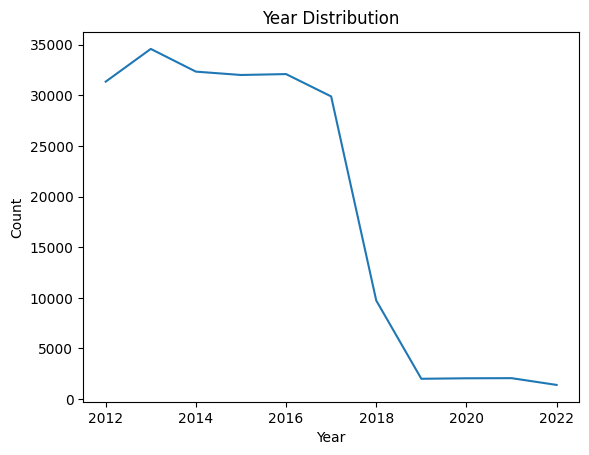

In [14]:
dt_arr=df['date'].dt.year.value_counts()
# The data we get from the value_count is sorted accoring to the value , we need it to sort that according to index.
xs,ys=zip(*sorted(zip(dt_arr.index,dt_arr.values)))
plt.plot(xs,ys)
plt.xlabel('Year')
plt.ylabel('Count')
plt.title('Year Distribution')
plt.show()

<Axes: ylabel='count'>

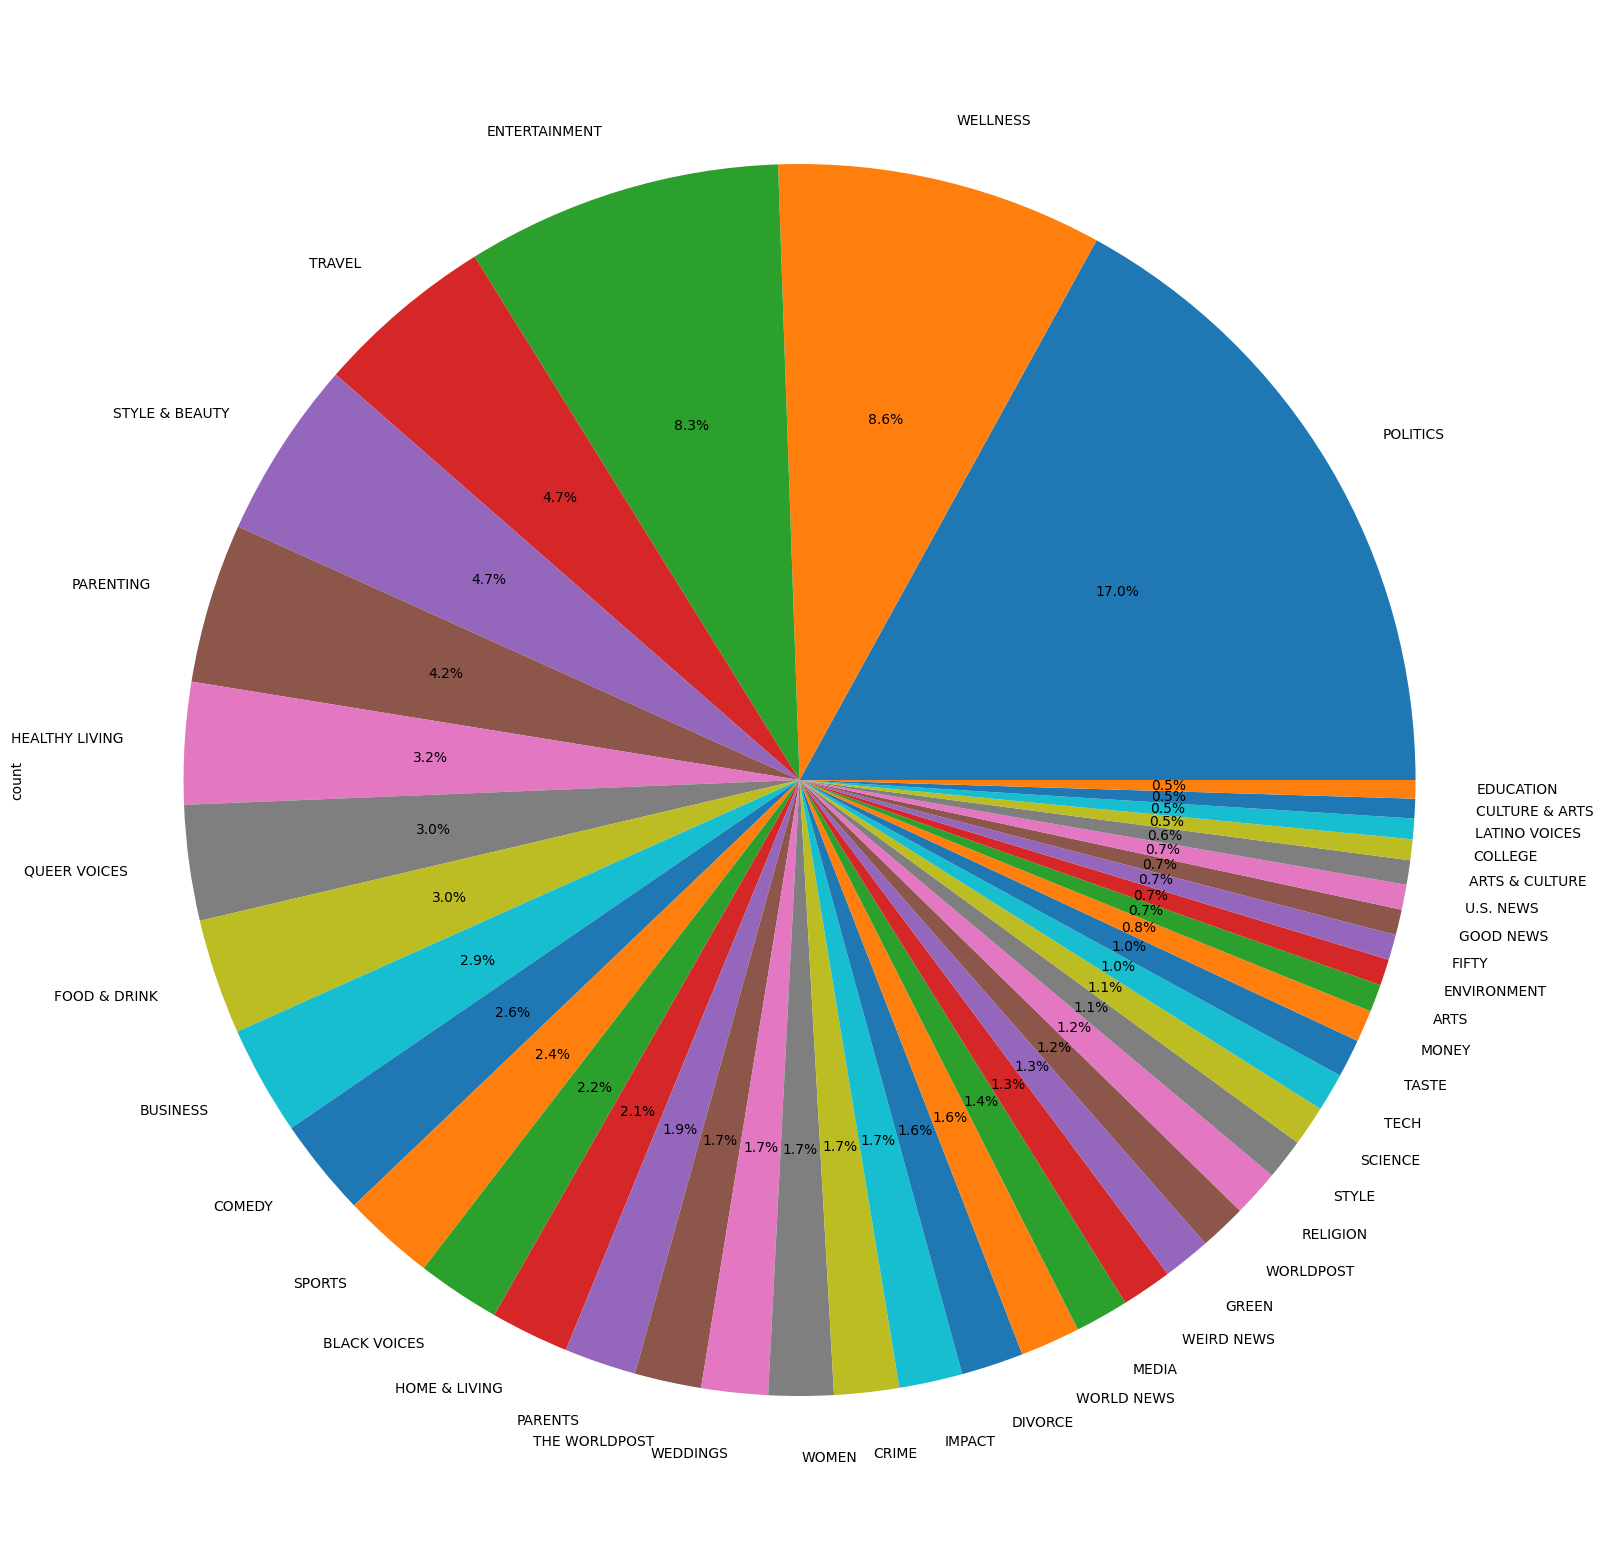

In [17]:
df['category'].value_counts().plot(kind='pie', figsize=(20,20), autopct='%1.1f%%',)